In [1]:
import sys
!{sys.executable} -m pip install seaborn matplotlib scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\ASUS\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


--- Veri Seti Genel Bilgisi ---
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str 

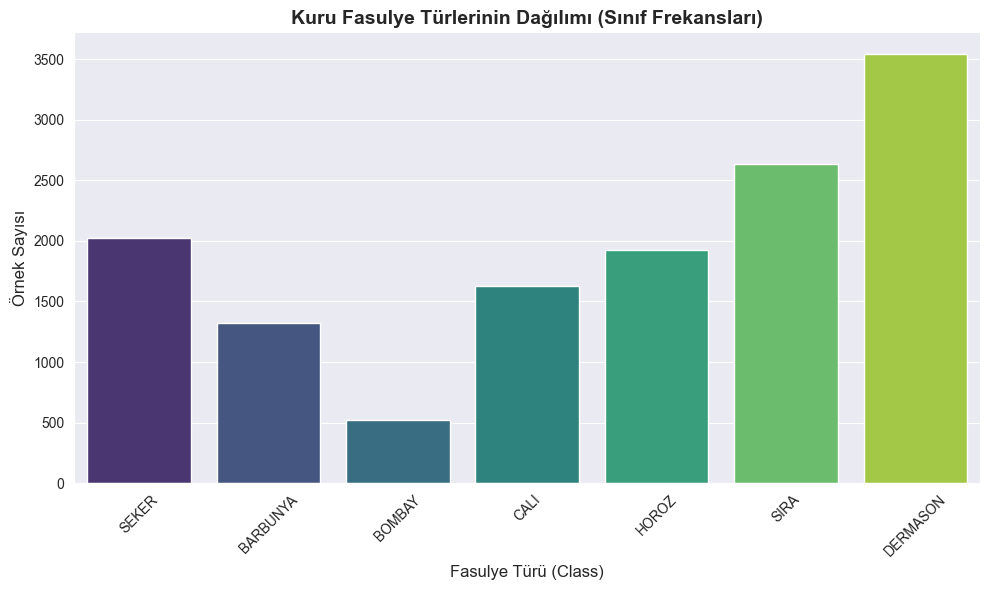

--- Her Bir Türden Kaç Adet Var? ---
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


In [3]:
#2.1 Hedef Değişken Analizi ve Sınıf Dengesizliği Grafiği
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi Excel'den okuyup 'df' adıyla hafızaya alıyoruz
df = pd.read_excel("../data/raw/Dry_Bean_Dataset.xlsx")

# 2. Eksik veri var mı kontrol edelim
print("--- Veri Seti Genel Bilgisi ---")
df.info()
print("\n" + "="*50 + "\n")

# 3. Fasulye türlerinin dağılımını görselleştirelim
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Class', hue='Class', palette='viridis', legend=False)
plt.title('Kuru Fasulye Türlerinin Dağılımı (Sınıf Frekansları)', fontsize=14, fontweight='bold')
plt.xlabel('Fasulye Türü (Class)', fontsize=12)
plt.ylabel('Örnek Sayısı', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/sinif_dagilimi.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Sayıları metin olarak da görelim
print("--- Her Bir Türden Kaç Adet Var? ---")
print(df['Class'].value_counts())

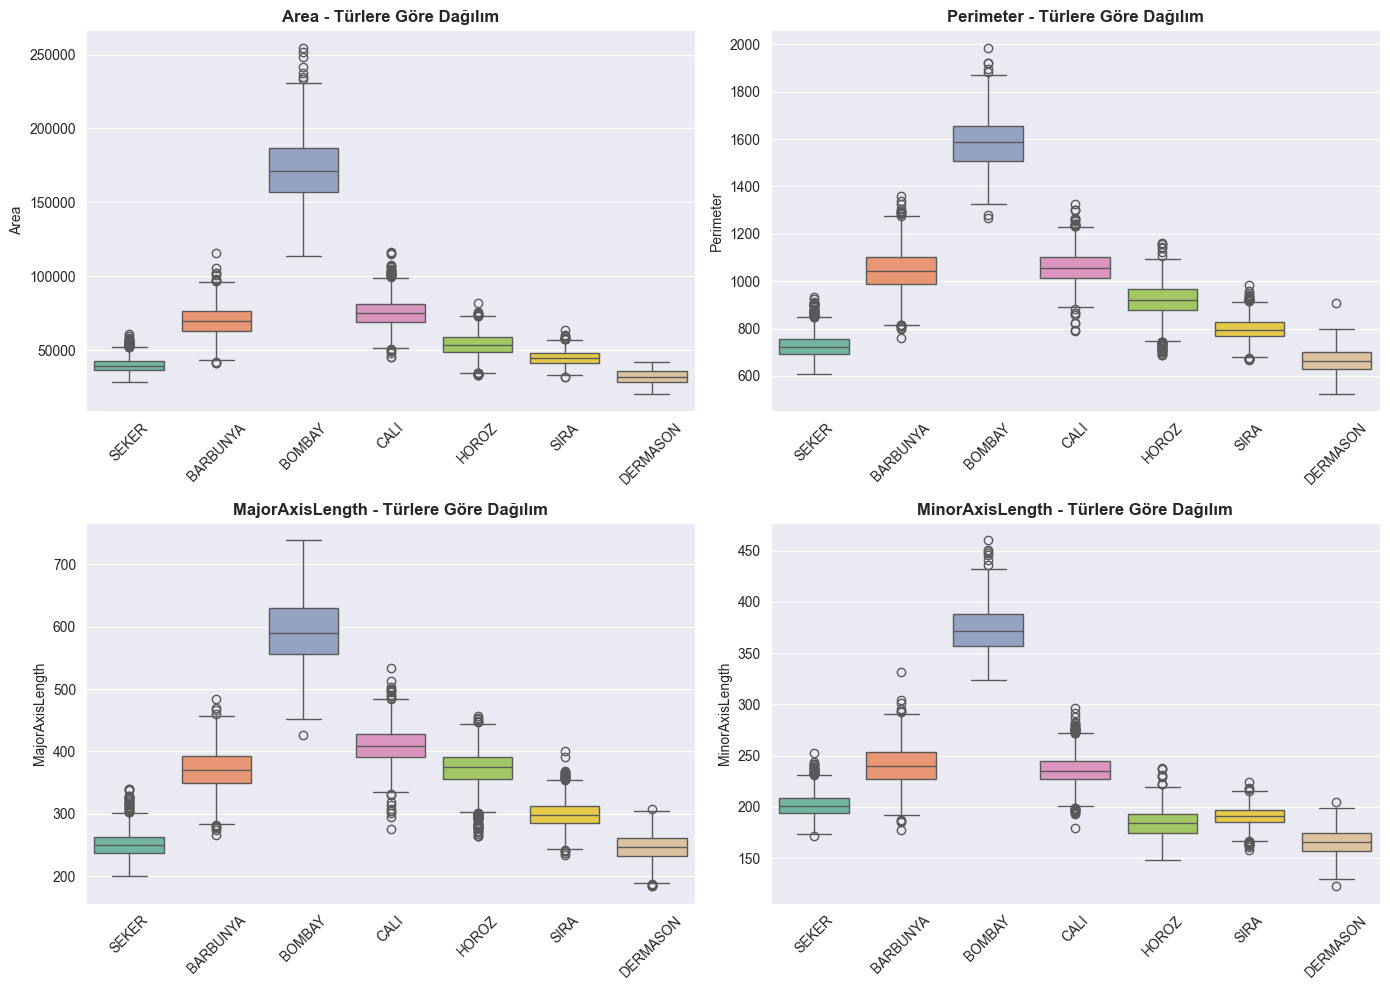

In [4]:
# # 2.2 Geometrik ve Şekilsel Değişkenlerin İstatistiksel Dağılımları
# Sadece sayısal olan bazı önemli özellikleri seçelim
features_to_plot = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength']

# 2x2'lik bir grafik alanı oluşturalım
plt.figure(figsize=(14, 10))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    # FutureWarning almamak için x ve y'yi açıkça belirttik, hue ekledik
    sns.boxplot(data=df, x='Class', y=feature, hue='Class', palette='Set2', legend=False)
    plt.title(f'{feature} - Türlere Göre Dağılım', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
    plt.ylabel(feature)
    plt.xlabel('')

plt.tight_layout()

# 1. Önce resmi hedef klasöre kaydediyoruz
plt.savefig('../reports/figures/geometrik_kutu_grafikleri.png', dpi=300, bbox_inches='tight')

# 2. Sonra ekranda gösteriyoruz
plt.show()

In [5]:
# 3.1 Eksik Veri Kontrolü
eksik_degerler = df.isnull().sum()

print("--- Sütunlardaki Eksik Değer Sayıları ---")
print(eksik_degerler)

# Toplam veri setinde hiç eksik veri var mı?
print("\nToplam Eksik Hücre Sayısı:", df.isnull().sum().sum())

--- Sütunlardaki Eksik Değer Sayıları ---
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Toplam Eksik Hücre Sayısı: 0


In [7]:
# 3.3 Aykırı Değer (Outlier) Temizleme - IQR Metodu
import numpy as np

def tur_bazli_iqr_temizligi(veri):
    # Temizlenmiş verileri biriktireceğimiz boş bir liste
    temizlenmis_parcalar = []

    # Sadece sayısal işlem yapılacak sütunları seçelim
    sayisal_sutunlar = veri.select_dtypes(include=[np.number]).columns

    # Her bir fasulye türü (Class) için döngüye gir
    for tur in veri['Class'].unique():
        # Sadece o türe ait verileri al
        tur_verisi = veri[veri['Class'] == tur].copy()

        # O türün her bir sayısal sütunu için IQR sınırlarını bul ve filtrele
        for sutun in sayisal_sutunlar:
            Q1 = tur_verisi[sutun].quantile(0.25)
            Q3 = tur_verisi[sutun].quantile(0.75)
            IQR = Q3 - Q1

            alt_sinir = Q1 - 1.5 * IQR
            ust_sinir = Q3 + 1.5 * IQR

            # Sınırların içinde kalan 'sağlıklı' fasulyeleri tut
            tur_verisi = tur_verisi[(tur_verisi[sutun] >= alt_sinir) & (tur_verisi[sutun] <= ust_sinir)]

        # Temizlenmiş bu türü listeye ekle
        temizlenmis_parcalar.append(tur_verisi)

    # Tüm temizlenmiş parçaları tek bir DataFrame'de birleştir
    temiz_df = pd.concat(temizlenmis_parcalar, ignore_index=True)
    return temiz_df

# Fonksiyonu çalıştıralım
print(f"Temizleme Öncesi Toplam Fasulye Sayısı: {len(df)}")

df_temiz = tur_bazli_iqr_temizligi(df)

print(f"Temizleme Sonrası Kalan Fasulye Sayısı: {len(df_temiz)}")
print(f"Silinen Toplam Aykırı (Hatalı) Fasulye Sayısı: {len(df) - len(df_temiz)}")

Temizleme Öncesi Toplam Fasulye Sayısı: 13611
Temizleme Sonrası Kalan Fasulye Sayısı: 11643
Silinen Toplam Aykırı (Hatalı) Fasulye Sayısı: 1968


In [8]:
# 4.1. Yeni Özelliklerin (Sütunların) Türetilmesi
import numpy as np

# 1. Şekil Karmaşıklığı: (Perimeter^2) / Area
df_temiz['Shape_Complexity'] = (df_temiz['Perimeter'] ** 2) / df_temiz['Area']

# 2. Yaklaşık 3D Hacim: Elipsoid Hacim Formülü -> 4/3 * pi * r1 * r2^2
# r1 = MajorAxisLength / 2
# r2 = MinorAxisLength / 2
df_temiz['Pseudo_Volume'] = (4/3) * np.pi * (df_temiz['MajorAxisLength'] / 2) * ((df_temiz['MinorAxisLength'] / 2) ** 2)

print("--- Yeni Türetilen Özellikler Başarıyla Eklendi ---")
print(df_temiz[['Class', 'Shape_Complexity', 'Pseudo_Volume']].head())

--- Yeni Türetilen Özellikler Başarıyla Eklendi ---
   Class  Shape_Complexity  Pseudo_Volume
0  SEKER         13.313924   3.666767e+06
1  SEKER         12.993745   3.724136e+06
2  SEKER         13.168986   3.750712e+06
3  SEKER         12.951306   3.722023e+06
4  SEKER         13.280066   3.803893e+06


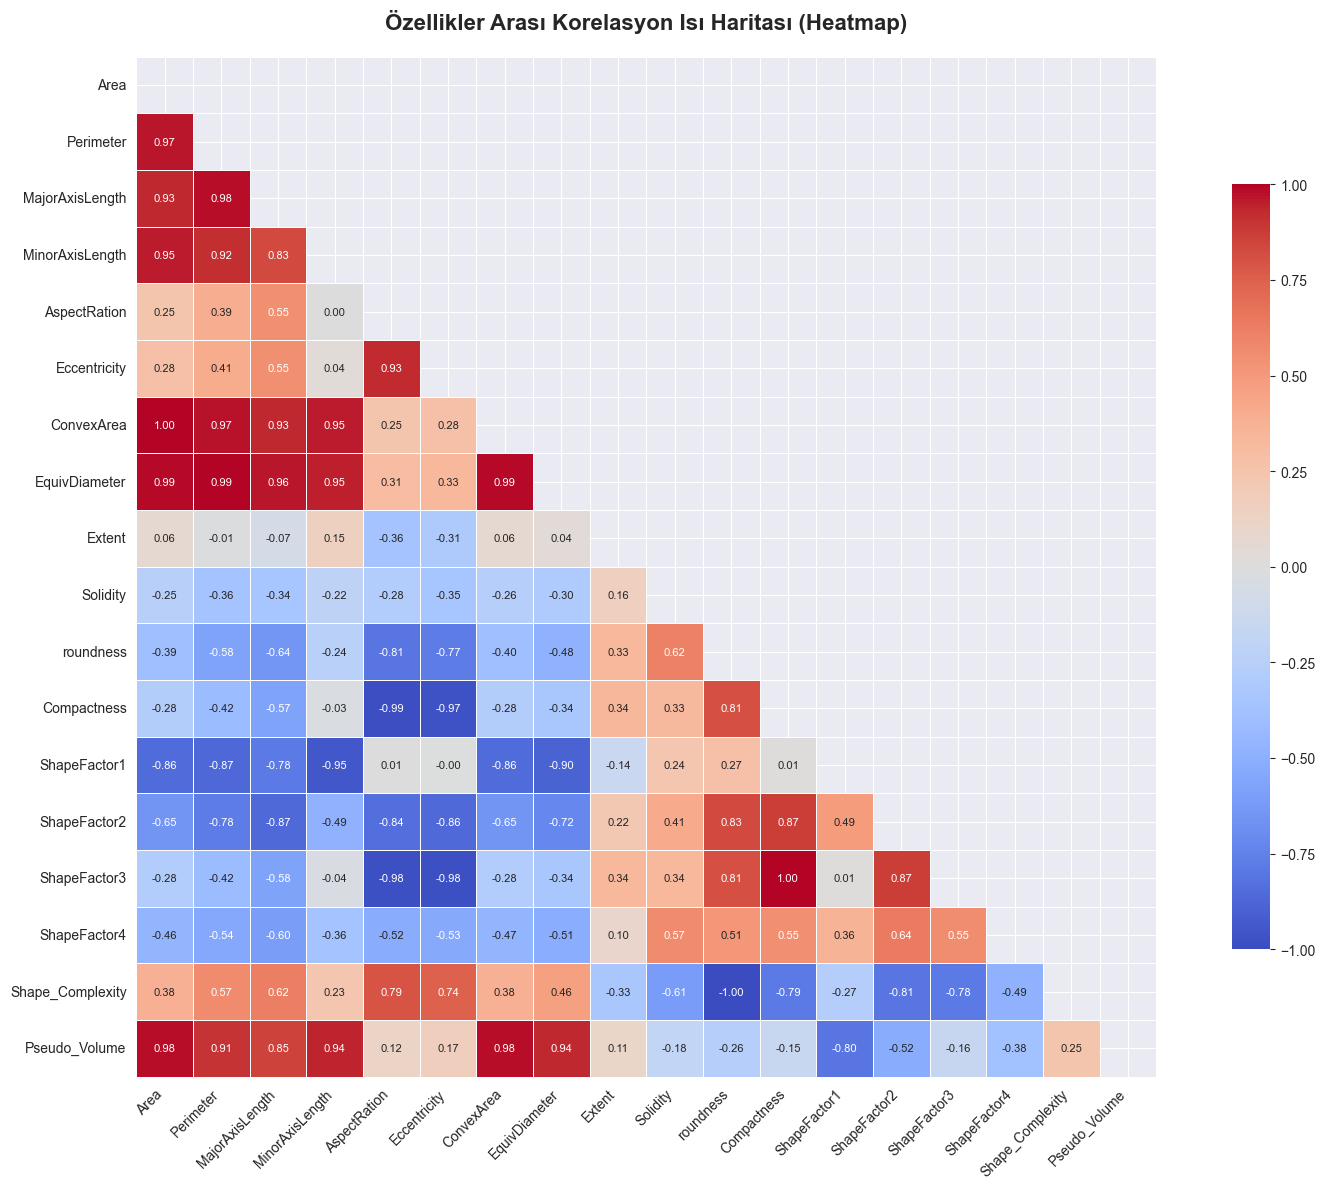

In [9]:
#4.2 Özellikler Arası İlişkiler: Korelasyon Analizi ve Isı Haritası (Heatmap)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sadece sayısal sütunları seç (Class sütununu dışarıda bırak)
sayisal_df = df_temiz.select_dtypes(include=[np.number])

# Korelasyon matrisini hesapla
korelasyon_matrisi = sayisal_df.corr()

# Profesyonel görünüm için grafiğin sadece alt üçgenini çizdirelim (maskeleme)
mask = np.triu(np.ones_like(korelasyon_matrisi, dtype=bool))

plt.figure(figsize=(16, 12))
plt.title('Özellikler Arası Korelasyon Isı Haritası (Heatmap)', fontsize=16, fontweight='bold', pad=20)

# Isı haritasını çiz
sns.heatmap(korelasyon_matrisi, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .75}, annot_kws={"size": 8})

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
# 1. Önce resmi hedef klasöre kaydediyoruz
plt.savefig('../reports/figures/korelasyon_heatmap.png', dpi=300, bbox_inches='tight')

# 2. Sonra ekranda gösteriyoruz
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 5.1. Veri Setinin Bağımsız (X) ve Bağımlı (Y) Değişkenler Olarak Ayrılması
X = df_temiz.drop('Class', axis=1)
y = df_temiz['Class']

# 5.2. Verinin Bölünmesi: Eğitim (Train) ve Test Setleri
# Veriyi %80 Eğitim, %20 Test olacak şekilde ayırıyoruz.
# stratify=y parametresi, sınıf dengesizliğini koruyarak adil dağıtım yapar.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Eğitim Verisi Sayısı (X_train): {X_train.shape[0]}")
print(f"Test Verisi Sayısı (X_test): {X_test.shape[0]}")

# 4.3. Data Leakage Olmadan Ölçeklendirme (Feature Scaling)
scaler = StandardScaler()

# DİKKAT: scaler'ı SADECE X_train üzerinde eğitiyoruz (fit) ve dönüştürüyoruz (transform)
X_train_scaled = scaler.fit_transform(X_train)

# Test verisine SADECE dönüştürme (transform) uyguluyoruz. Asla fit yapmıyoruz!
X_test_scaled = scaler.transform(X_test)

print("\n--- Train ve Test Verileri Başarıyla Bölündü ve Sızıntısız Ölçeklendirildi ---")

Eğitim Verisi Sayısı (X_train): 9314
Test Verisi Sayısı (X_test): 2329

--- Train ve Test Verileri Başarıyla Bölündü ve Sızıntısız Ölçeklendirildi ---


In [11]:
# 5.3. K-Fold Çapraz Doğrulama (Cross-Validation) Entegrasyonu
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, accuracy_score

print("5.3. K-Fold Çapraz Doğrulama Hesaplanıyor (K=5)... Lütfen bekleyin...")

# SVM Modelini Tanımlıyoruz
# kernel='rbf' : Doğrusal olmayan ilişkiler için
# class_weight='balanced' : Sınıf dengesizliğini çözmek için
svm_model = SVC(kernel='rbf', random_state=42, class_weight='balanced')

# SADECE Eğitim verisi üzerinde modeli 5 farklı parçaya bölüp test ediyoruz
cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print(f"K-Fold (K=5) Ayrıntılı Skorları: {cv_scores}")
print(f"K-Fold Ortalama Doğruluk (Validation Accuracy): % {cv_scores.mean() * 100:.2f}\n")

# 5.4. Destek Vektör Makineleri (SVM) Model Mimarisi Eğitimi ve Testi

print("5.4. Model tüm eğitim verisiyle eğitiliyor...")
svm_model.fit(X_train_scaled, y_train)
print("Eğitim tamamlandı!\n")

# Sınav Aşaması (Test Seti ile modelin hiç görmediği veride tahmin yapması)
y_pred = svm_model.predict(X_test_scaled)

print("--- SVM Modeli Test Sonuçları ---")
print(f"Genel Doğruluk (Accuracy) Oranı: % {accuracy_score(y_test, y_pred) * 100:.2f}\n")
print("Sınıflandırma Raporu (Classification Report):")
print(classification_report(y_test, y_pred))

5.3. K-Fold Çapraz Doğrulama Hesaplanıyor (K=5)... Lütfen bekleyin...
K-Fold (K=5) Ayrıntılı Skorları: [0.95222759 0.95813205 0.9538379  0.94954375 0.94575725]
K-Fold Ortalama Doğruluk (Validation Accuracy): % 95.19

5.4. Model tüm eğitim verisiyle eğitiliyor...
Eğitim tamamlandı!

--- SVM Modeli Test Sonuçları ---
Genel Doğruluk (Accuracy) Oranı: % 96.14

Sınıflandırma Raporu (Classification Report):
              precision    recall  f1-score   support

    BARBUNYA       0.98      0.96      0.97       228
      BOMBAY       1.00      1.00      1.00        91
        CALI       0.96      0.98      0.97       288
    DERMASON       0.96      0.93      0.94       622
       HOROZ       1.00      0.99      1.00       307
       SEKER       0.96      0.99      0.98       330
        SIRA       0.92      0.94      0.93       463

    accuracy                           0.96      2329
   macro avg       0.97      0.97      0.97      2329
weighted avg       0.96      0.96      0.96      2329

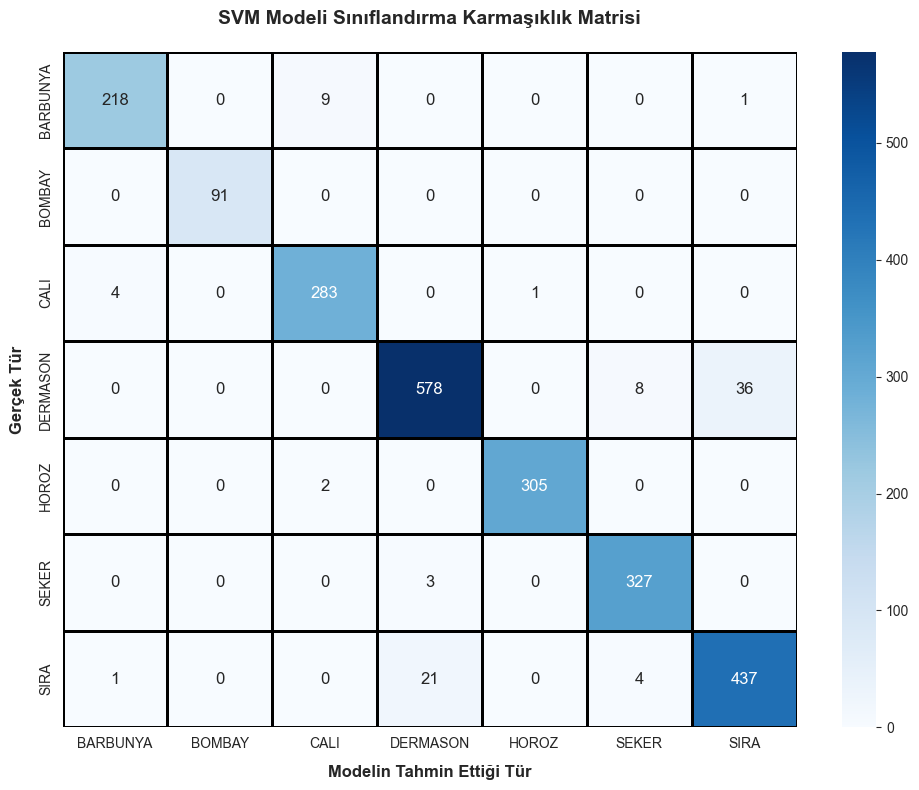

--- Karmaşıklık Matrisi başarıyla çizildi ve 'confusion_matrix_svm.png' olarak kaydedildi! ---


In [12]:
# 6.1. Karmaşıklık Matrisi (Confusion Matrix) Görselleştirmesi
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Karmaşıklık matrisinin matematiğini hesaplıyoruz
cm = confusion_matrix(y_test, y_pred)
sinif_isimleri = svm_model.classes_

plt.figure(figsize=(10, 8))

# Seaborn kütüphanesi ile ısı haritası (Heatmap) çizimi
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sinif_isimleri, yticklabels=sinif_isimleri,
            annot_kws={"size": 12}, linewidths=1, linecolor='black')

plt.title('SVM Modeli Sınıflandırma Karmaşıklık Matrisi', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Modelin Tahmin Ettiği Tür', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Gerçek Tür', fontsize=12, fontweight='bold', labelpad=10)


plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_svm.png', dpi=300, bbox_inches='tight')

plt.show()
print("--- Karmaşıklık Matrisi başarıyla çizildi ve 'confusion_matrix_svm.png' olarak kaydedildi! ---")